In [2]:
import numpy as np
import IPython.display as display

from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime.fake_provider import FakeManilaV2

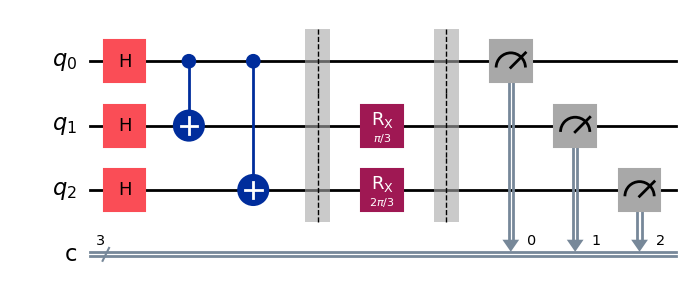

In [14]:
cr = ClassicalRegister(3, 'c')
qr = QuantumRegister(3, 'q') 
qc = QuantumCircuit(qr, cr)

# Apply hadamard to first qubits
qc.h(qr)
# Apply CNOT gate to create Bell state q0 and q1
qc.cx(qr[0], qr[1])
qc.cx(qr[0], qr[2])
qc.barrier()

qc.rx(np.pi/3, qr[1])
qc.rx(2*np.pi/3, qr[2])
qc.barrier()

qc.measure(qr, cr)

qc.draw('mpl')

In [4]:
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace, state_fidelity

prep_state=[np.sqrt(1/3), np.sqrt(2/3)]

qc = QuantumCircuit(3)

# Prepared unknown psi state
qc.initialize(prep_state, 0)

# Prepared bell pair
qc.h(1)
qc.cx(1, 2)

# q0 entangled with half bell pair
qc.cx(0, 1)

# Adjusted basis of measurement to include phase shift
qc.h(0)

# Controlled X quantum correction
qc.cx(1, 2)

# Controlled Z quantum correction
qc.cz(0, 2)

# Run the circuit to get statevector
sv = Statevector.from_instruction(qc)

# Initial state q0 |psi>:
psi = Statevector(prep_state)

# Get density matrix of q2:
dm = DensityMatrix(sv) # ρ=∣ψ⟩⟨ψ∣, ⟨ψ∣ is conjugate tranpose of ∣ψ⟩
dm_q2 = partial_trace(dm, [0, 1])  # trace out q0 and q1, ρ_q2​=Tr_(q0,q1​).(ρfull​)

# fidelity between pure psi and rho:
fid = state_fidelity(psi, dm_q2) # F(∣ψ⟩,∣ϕ⟩)=∣⟨ψ∣ϕ⟩∣^2

print('state vectoir', sv)
print('density matrix', dm)
print('partial trace', dm_q2)
print('fidelity', fid)

state vectoir Statevector([0.28867513+0.j, 0.28867513+0.j, 0.28867513+0.j,
             0.28867513+0.j, 0.40824829+0.j, 0.40824829+0.j,
             0.40824829+0.j, 0.40824829+0.j],
            dims=(2, 2, 2))
density matrix DensityMatrix([[0.08333333+0.j, 0.08333333+0.j, 0.08333333+0.j,
                0.08333333+0.j, 0.11785113+0.j, 0.11785113+0.j,
                0.11785113+0.j, 0.11785113+0.j],
               [0.08333333+0.j, 0.08333333+0.j, 0.08333333+0.j,
                0.08333333+0.j, 0.11785113+0.j, 0.11785113+0.j,
                0.11785113+0.j, 0.11785113+0.j],
               [0.08333333+0.j, 0.08333333+0.j, 0.08333333+0.j,
                0.08333333+0.j, 0.11785113+0.j, 0.11785113+0.j,
                0.11785113+0.j, 0.11785113+0.j],
               [0.08333333+0.j, 0.08333333+0.j, 0.08333333+0.j,
                0.08333333+0.j, 0.11785113+0.j, 0.11785113+0.j,
                0.11785113+0.j, 0.11785113+0.j],
               [0.11785113+0.j, 0.11785113+0.j, 0.11785113+0.j,
   